In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/student_grades.csv")
df.drop(columns=["noisy_letter_grade"], inplace=True)

print(df.shape)
df.head()

(941, 6)


,stud_ID,exam_1,exam_2,exam_3,notes,letter_grade
0,f48f73,53,77,93,NaN,C
1,0bd4e7,81,64,80,great participation +10,B
2,e1795d,74,88,97,NaN,B
3,cb9d7a,61,94,78,NaN,C
4,9acca4,48,90,91,NaN,C


In [ ]:
# Convert letter grades to pass/fail, binary classification problem.
df["pass"] = df["letter_grade"].isin(["A", "B", "C"]).astype(int)

df["s"] = 0

# For each student who passed (pass=1), flip a coin with p=0.8.
# If it lands heads, mark s=1 (labeled positive). If tails, leave s=0 (unlabeled).
#
# This simulates the PU-learning setup:
# - 'pass' is the hidden true label y (positive/negative).
# - 's' is the observed label flag (only some positives are labeled, negatives never are).

# Training on s instead of pass creates the "nontraditional" binary classification problem described in the paper.
mask = df["pass"] == 1

# Each passing student has a 80% chance of being labeled
df.loc[mask, "s"] = np.random.binomial(1, 0.2, size=mask.sum())

print(df["pass"].value_counts())
print(df["s"].value_counts())

number_of_positives = len(df.loc[df["pass"] == 1])
number_of_labeleds = len(df.loc[df["s"] == 1])

print(f"\nNumber of hidden positives: {number_of_positives - number_of_labeleds}")

pass
1    717
0    224
Name: count, dtype: int64
s
0    794
1    147
Name: count, dtype: int64

Number of hidden positives: 570


In [ ]:
from sklearn.model_selection import train_test_split

feature_columns = ["exam_1", "exam_2", "exam_3", "notes"]
predicted_column = "s"

X = df[feature_columns]
y_s = df[predicted_column]  # observed label for training
y_pass = df["pass"]  # true label for evaluation

categorical_features = ["notes"]
X = pd.get_dummies(X, columns=categorical_features)

# Split the data into train/test (80% train, 20% test)
X_train, X_test, y_s_train, y_s_test, y_pass_train, y_pass_test = train_test_split(
    X, y_s, y_pass, test_size=0.2, random_state=0
)

# Exercise
Implement one of the Calibrated Models from the list and compare results!

1. LogisticRegression.
2. Naive Bayes.
3. others...

Or use a Non Calibrated Model and perform calibration.

1. SVM.
2. Gaussian NB.
3. RandomForest.
4. Decision Tree.
5. XGBoost.

For calibrating you can use CalibratedClassifierCV from SKLearn

In [ ]:
# for this exercise, I want to define calibrated model as logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV

model = LogisticRegression()
model = CalibratedClassifierCV(model)
model.fit(X_train, y_s_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

CalibratedClassifierCV(estimator=LogisticRegression())

In [ ]:
from sklearn.metrics import f1_score

predictions = model.predict(X_test)

# Evaluate Non Traditional Classifier against TRUE pass labels
f1  = f1_score(y_pass_test, predictions)

g = model.predict_proba(X_test)[:, 1]
g_test  = model.predict_proba(X_test)[:, 1]

# Estimator #1
c_estimate = g[y_s_test == 1].mean()
print(f"C_estimate (estimate of p(s=1|y=1)): {c_estimate:.3f}")
print(f"Actual C: {number_of_labeleds / number_of_positives:.3f}\n")

f_test = np.clip(g_test / c_estimate, 0.0, 1.0)

# Turn probabilities into pass/fail predictions with a threshold
y_pred_pass = (f_test >= 0.5).astype(int)


print(f"Non Traditional Classifier — F1: {f1:.3f}")

# Evaluate PU Learning Classifier against TRUE pass labels
pu_f1  = f1_score(y_pass_test, y_pred_pass)
print(f"PU Learning Classifier — F1: {pu_f1:.3f}")

# C_estimate (estimate of p(s=1|y=1)): 0.199
# Actual C: 0.192

# Non Traditional Classifier — F1: 0.000
# PU Learning Classifier — F1: 0.924

C_estimate (estimate of p(s=1|y=1)): 0.191
Actual C: 0.205

Non Traditional Classifier — F1: 0.000
PU Learning Classifier — F1: 0.944


In [ ]:
# Visualize results
results = X_test.copy()

results = results.loc[:,~results.columns.str.startswith('notes')]

results["pred_prob_non_pu"] = predictions
results["pred_pass_pu"] = y_pred_pass
results["true_pass"] = y_pass_test.values

results.head(10)

,exam_1,exam_2,exam_3,pred_prob_non_pu,pred_pass_pu,true_pass
571,97,94,76,0,1,1
304,76,84,67,0,1,1
308,91,61,100,0,1,1
590,69,87,70,0,1,0
614,100,62,61,0,0,0
299,0,71,80,0,0,0
686,72,91,91,0,1,1
867,100,100,87,0,1,1
14,67,82,98,0,1,1
439,90,99,90,0,1,1


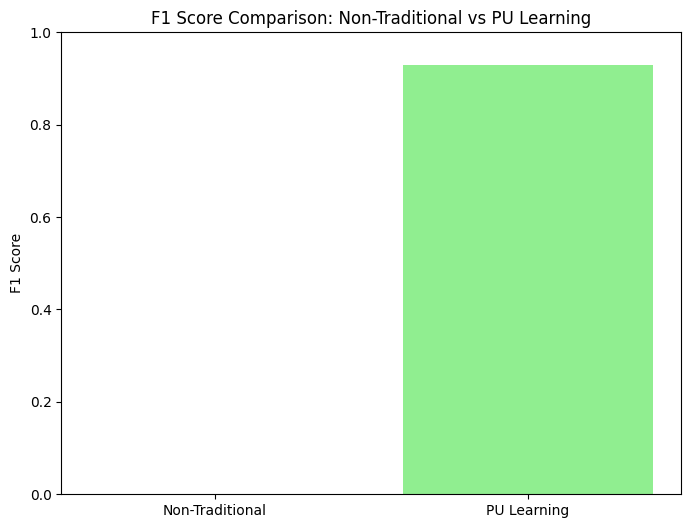

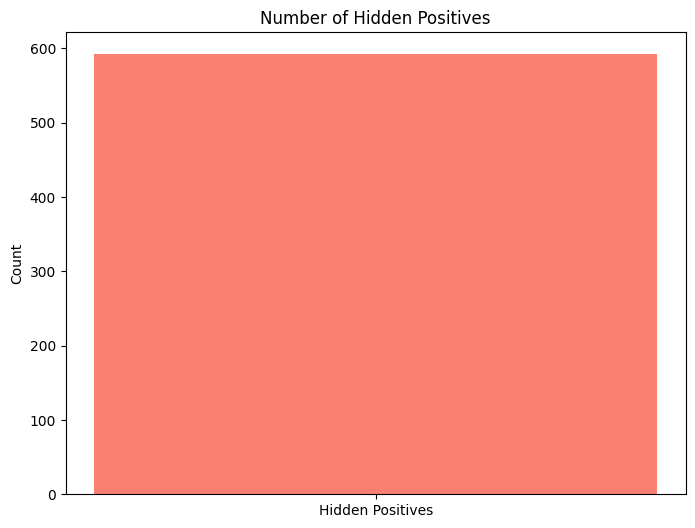

In [ ]:
# Plot of Hidden postivies count vs F1

import matplotlib.pyplot as plt

# Assuming you have calculated the F1 score for both classifiers and the number of hidden positives
# Replace these with your actual calculated values
f1_non_traditional = f1
f1_pu_learning = pu_f1
hidden_positives = number_of_positives - number_of_labeleds


plt.figure(figsize=(8, 6))
plt.bar(['Non-Traditional', 'PU Learning'], [f1_non_traditional, f1_pu_learning], color=['skyblue', 'lightgreen'])
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison: Non-Traditional vs PU Learning')
plt.ylim(0, 1) # F1 score is between 0 and 1
plt.show()

plt.figure(figsize=(8, 6))
plt.bar(['Hidden Positives'], [hidden_positives], color='salmon')
plt.ylabel('Count')
plt.title('Number of Hidden Positives')
plt.show()

![Plot of Hidden postivies count vs F1](./f1.png)